### **Imports** 

In [1]:
import numpy as np
import sys, os
from autograd import grad, hessian
import numpy as np
# import autograd.numpy as np
import matplotlib.pyplot as plt
import sklearn
from sklearn import svm
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.metrics import balanced_accuracy_score
import pandas as pd
from utils import *
from sklearn.preprocessing import OneHotEncoder
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
import matplotlib.colors as mcolors

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV, PredefinedSplit
import joblib


In [2]:
import joblib
print(joblib.cpu_count())


1


### **Using Support Vector Machines for Nonlinear Classification** <br>


In [2]:
#Load the data 

data = np.load('../../data_splits_splot22f_1008.npz')

X_train = data['X_train']
y_train = data['y_train'][:, :1]
X_val = data['X_val']
y_val = data['y_val'][:, :1]
X_test = data['X_test']
y_test = data['y_test'][:, :1]

#Standard normalize the training data and use the mean and std to normalize the testing data
svc_scaler = StandardScaler().fit(X_train)
X_train = svc_scaler.transform(X_train)
X_val = svc_scaler.transform(X_val)
X_test = svc_scaler.transform(X_test)


print("Training set ", np.shape(X_train), np.shape(y_train))
print("Validation set ", np.shape(X_val), np.shape(y_val))
print("Testing set ", np.shape(X_test), np.shape(y_test))

Training set  (17739, 5) (17739,)
Validation set  (3801, 5) (3801,)
Testing set  (3802, 5) (3802,)


For the kernel in the `SVM`, I chose the `Radial Basis Function (RBF)` kernel because it offers flexibility in shaping the decision boundary. This kernel has two parameters: `C` and `gamma`. The parameter `C` acts as an inverse regularizer, where lower values of `C` lead to simpler decision boundaries. Gamma controls how much influence a single training example has. Since I'm unsure which values of `C` and `gamma` to begin with, I use `Grid Search` to find the optimal combination of these parameters. Additionally, I have addressed class imbalances by using the `class_weight` parameter, which assigns higher weights to the underrepresented classes.


In [4]:
#Performing one-versus-rest and grid search

# Create a split indicator array
# -1 means "use for training", 0 means "use for validation"
split_index = np.concatenate([
    np.full(len(X_train), -1),  # All train samples get -1
    np.zeros(len(X_val))         # All val samples get 0
])

# Combine train and validation sets
X_train_val = np.vstack([X_train, X_val])
y_train_val = np.hstack([y_train, y_val])

# Create the predefined split
ps = PredefinedSplit(test_fold=split_index)

parameters = {'kernel':[('rbf', 'poly')], 'C':[ 0.1, 1, 10, 100, 1000, 10000], 'gamma':[0.001, 0.01, 0.1, 1], 'degree':[2,3]}

parameters = {'kernel':[('rbf')], 'C':[ 1, 10, 100, 1000, 10000, 100000], 'gamma':[ 0.01, 0.1, 1]}
            
svc = svm.SVC(decision_function_shape='ovr', class_weight='balanced')
svc = GridSearchCV(svc, parameters, scoring = 'balanced_accuracy', cv = ps, n_jobs=-1)
svc.fit(X_train_val, y_train_val)

# Save the best-performing model 
joblib.dump(svc.best_estimator_, 'models/svm_best_model.pkl')
joblib.dump(svc_scaler, 'models/svm_scaler.pkl')

# Also save best parameters for reference
results = {
    'best_params': svc.best_params_,
    'best_score': svc.best_score_,
    'cv_results': svc.cv_results_
}

joblib.dump(results, 'models/svm_training_info.pkl')

model = svc.best_estimator_

# Generate predictions
y_pred_train = model.predict(X_train)
y_pred_val = model.predict(X_val)
y_pred_test = model.predict(X_test)

print("Test Accuracy: {:.3f}%".format(accuracy_score(y_test, y_pred_test)*100))
print("Test Balanced Accuracy: {:.3f}%".format(balanced_accuracy_score(y_test, y_pred_test)*100))


# Save everything you'll need for plotting
np.savez('results/svm_results.npz',
         y_pred_train=y_pred_train,
         y_pred_val=y_pred_val,
         y_pred_test=y_pred_test,
)


Test Accuracy: 97.975%
Test Balanced Accuracy: 96.839%


In [17]:
# ----- Load training info -----
results = joblib.load('best_models/svm_training_info.pkl')
best_model = joblib.load('best_models/svm_best_model.pkl')
# scaler = 

print("Best Parameters:")
print(results['best_params'])
print("\nBest Cross-Validation Score: {:.3f}%".format(results['best_score'] * 100))

# svc_scaler.transform(X_grid)
y_test_predicted = best_model.predict(X_test)
print("Test Accuracy: {:.3f}%".format(accuracy_score(y_test, y_test_predicted)*100))


Best Parameters:
{'C': 10000, 'degree': 2, 'gamma': 0.1, 'kernel': 'rbf'}

Best Cross-Validation Score: 95.488%


Test Accuracy: 51.131%


<Axes: title={'center': 'SVC'}, xlabel='Predicted', ylabel='True'>

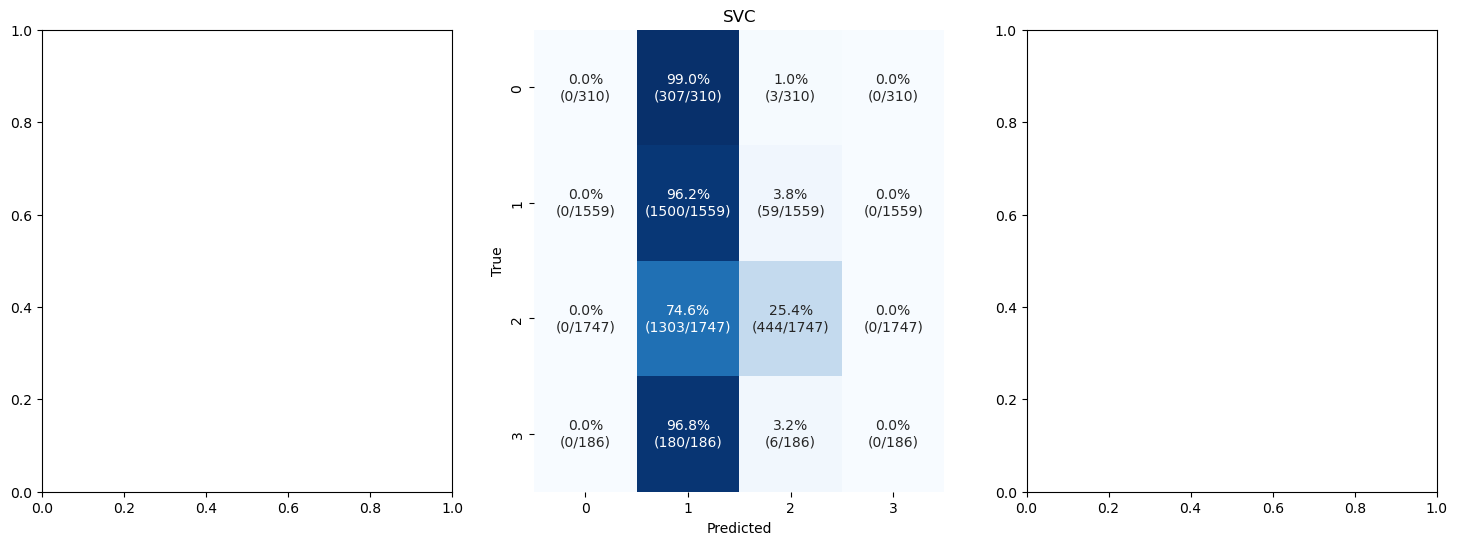

In [16]:
# Create panel with all three
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

svm_results = np.load('results/svm_results.npz', allow_pickle=True)
y_pred_svm = svm_results['y_pred_test']
gen_confusion_matrix(y_test, y_test_predicted, 'SVC', ax=axes[1])

In [37]:
def N_svc_gridsearch_plotter(X_train, y_train, X_test, y_test, svc, svc_scaler,feature_idx=(0, 1), fixed_values={}, labels = []):

    # Step 1: Filter train and test data based on fixed_values
    
    train_mask = np.all(np.array([np.isclose(X_train[:, k], v, rtol=0.09) for k, v in fixed_values.items()]), axis=0)
    test_mask = np.all(np.array([np.isclose(X_test[:, k], v, rtol=0.09) for k, v in fixed_values.items()]), axis=0)


    X_train_filtered, y_train_filtered = X_train[train_mask], y_train[train_mask]
    X_test_filtered, y_test_filtered = X_test[test_mask], y_test[test_mask]

    #--- Plot predictions ---#
    
    # Create a mesh grid
    # Step 2: Create a meshgrid for the chosen two features
    x_min, x_max = X_train[:, feature_idx[0]].min() - 0.1, X_train[:, feature_idx[0]].max() + 0.1
    y_min, y_max = X_train[:, feature_idx[1]].min() - 0.1, X_train[:, feature_idx[1]].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
    print(x_min, x_max)
    # Step 3: Construct full-dimensional input space for predictions
    X_grid = np.zeros((xx.ravel().shape[0], X_train.shape[1]))
    X_grid[:, feature_idx[0]] = xx.ravel()
    X_grid[:, feature_idx[1]] = yy.ravel()

    # Assign fixed values to other dimensions
    for k, v in fixed_values.items():
        X_grid[:, k] = v  

    #transform the data
    X_grid_scaled = svc_scaler.transform(X_grid)
 
    #Predict labels for meshgrid
    best_model = svc.best_estimator_
    Z = best_model.predict(X_grid_scaled)
    Z = Z.reshape(xx.shape)

    # Normalize color mapping to match the scatter points and contour
    cmap = plt.cm.coolwarm  # Set the same colormap
    norm = mcolors.Normalize(vmin=Z.min(), vmax=Z.max())  # Normalize colors

    # Plot decision boundary
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=cmap, norm=norm)

    #--- Overplot the data ---#

    plt.scatter(X_train_filtered[:, feature_idx[0]], X_train_filtered[:, feature_idx[1]],  c=y_train_filtered,  cmap='coolwarm',  edgecolor="k", marker='o', label = 'Train' )
    plt.scatter(X_test_filtered[:, feature_idx[0]], X_test_filtered[:, feature_idx[1]],  c=y_test_filtered, cmap='coolwarm', edgecolor="k" , marker='x', label = 'Test')

    #--- Plot settings ---#

    plt.title(f"SVM: Decision Boundary Mass1 = {labels[2]} Msun , Mass2 = {labels[3]}Msun")
    plt.xlabel(f" {labels[0]}")
    plt.ylabel(f" {labels[1]}")
    plt.legend()
    plt.show()

In [6]:
def load_and_plot_SVC(feature_idx, fixed_values={}, labels=[]):

    # --- Load saved model, scaler, and results ---
    model = joblib.load('models/svm_best_model.pkl')
    scaler = joblib.load('models/svm_scaler.pkl')
    results = joblib.load('models/svm_training_info.pkl')
    preds = np.load('results/svm_results.npz')

    data = np.load('data_splits_splot22f.npz')
    X_train, y_train = data['X_train'], data['y_train']
    # X_val, y_val = data['X_val'], data['y_val']
    X_test, y_test = data['X_test'], data['y_test']



    # --- Generate the plot ---
    N_svc_gridsearch_plotter(X_train, y_train, X_test, y_test,
                             svc=model,
                             svc_scaler=scaler,
                             feature_idx=feature_idx,
                             fixed_values=fixed_values,
                             labels=labels)


def N_svc_gridsearch_plotter(X_train, y_train, X_test, y_test, svc, svc_scaler, feature_idx, fixed_values={}, labels = [], num_classes = 4):

    # Xtrain is not standard normalized, neither are the features and fixed values, but they are given in the correct transformstion 

    # Step 1: Filter train and test data based on fixed_values
    print(fixed_values)
    # train_mask = np.all(np.array([np.isclose(X_train[:, k], v, rtol=0.009) for k, v in fixed_values.items()]), axis=0)
    # test_mask = np.all(np.array([np.isclose(X_test[:, k], v, rtol=0.009) for k, v in fixed_values.items()]), axis=0)

    train_mask = np.logical_and.reduce([np.isclose(X_train[:, k], v, rtol=0.01) for k, v in fixed_values.items()])
    test_mask = np.logical_and.reduce([np.isclose(X_test[:, k], v, rtol=0.01) for k, v in fixed_values.items()])

    X_train_filtered, y_train_filtered = X_train[train_mask], y_train[train_mask]
    X_test_filtered, y_test_filtered = X_test[test_mask], y_test[test_mask]

    #--- Plot predictions ---#
    
    # Create a mesh grid
    # Step 2: Create a meshgrid for the chosen two features
    x_min, x_max = X_train_filtered[:, feature_idx[0]].min() -0.1, X_train_filtered[:, feature_idx[0]].max() + 0.01
    y_min, y_max = X_train_filtered[:, feature_idx[1]].min() -0.1, X_train_filtered[:, feature_idx[1]].max()  + 0.1
    
    print(x_min, x_max)
    print(X_train_filtered[:, feature_idx[0]].max())
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500), np.linspace(y_min, y_max, 500))
    
    # Step 3: Construct full-dimensional input space for predictions
    X_grid = np.zeros((xx.ravel().shape[0], X_train.shape[1]))
    X_grid[:, feature_idx[0]] = xx.ravel()
    X_grid[:, feature_idx[1]] = yy.ravel()

    # Assign fixed values to other dimensions
    for k, v in fixed_values.items():
        X_grid[:, k] = v  

    #transform the data
    X_grid_scaled = svc_scaler.transform(X_grid)
 
    #Predict labels for meshgrid
    best_model = joblib.load('models/svm_best_model.pkl')
    Z = best_model.predict(X_grid_scaled)
    Z = Z.reshape(xx.shape)

    # # Normalize color mapping to match the scatter points and contour
    # cmap = plt.cm.coolwarm  # Set the same colormap
    # norm = mcolors.Normalize(vmin=Z.min(), vmax=Z.max())  # Normalize colors

    # Normalize color mapping to match the scatter points and contour
    cmap = plt.cm.coolwarm  # Set the same colormap
    norm = mcolors.Normalize(vmin=0, vmax=2)  # Normalize colors

    if num_classes >= 4: 

        cmap_base = plt.cm.coolwarm
        norm_base = mcolors.Normalize(vmin=0, vmax=2)
        # Build a list of colors by evaluating cmap for labels 0, 1, 2, 3
        colors = [cmap_base(norm_base(i)) for i in range(num_classes)]

        # Append a custom color for label 3 (e.g., green)
        colors.append((0.13, 0.55, 0.13, 1.0))  # green

        # Create a discrete colormap
        cmap = mcolors.ListedColormap(colors)

        # Define norm for discrete class labels 0–3
        norm = mcolors.BoundaryNorm(boundaries=[-0.5, 0.5, 1.5, 2.5, 3.5], ncolors=4)

    # Plot decision boundary
    plt.contourf(10**xx-1, yy, Z, alpha=0.3, cmap=cmap, norm=norm)
    # plt.xlim(x_min-0.1, x_max)
    #--- Overplot the data ---#

    plt.scatter(10**X_train_filtered[:, feature_idx[0]]-1, X_train_filtered[:, feature_idx[1]],  c=y_train_filtered,  cmap=cmap, norm = norm,  edgecolor="k", marker='o', label = 'Train' )
    plt.scatter(10**X_test_filtered[:, feature_idx[0]]-1, X_test_filtered[:, feature_idx[1]],  c=y_test_filtered, cmap=cmap, norm = norm, edgecolor="k" , marker='^', label = 'Test')

    #--- Plot settings ---#

    plt.title(
    fr"SVM $\mathrm{{M_1}} = {labels[2]}\ M_\odot,\ \mathrm{{M_2}} = {labels[3]}\ M_\odot,\ \mathrm{{Time}} = {round(10**(float(labels[4])),3)}\ \mathrm{{Gyr}}$", fontsize = 17)
    plt.xlabel(fr" {labels[0]}", fontsize = 15)
    plt.ylabel(fr" {labels[1]}", fontsize = 15)
    plt.legend()
    plt.show()
    plt.tight_layout()

{0: np.float64(0.0), 3: np.float64(0.0), 4: np.float64(-0.2231435513142097)}
-0.1 0.4296088349081029
0.4196088349081029


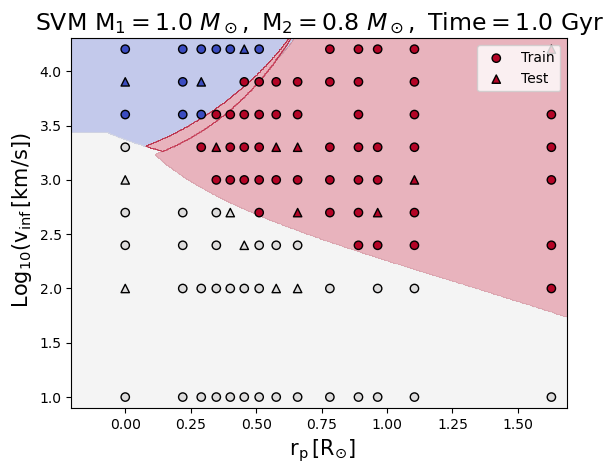

<Figure size 640x480 with 0 Axes>

In [8]:

# unique_rows = unique_rows.T
unique_rows = np.array([[1.0,0.8]])
time = 1
for unique in unique_rows:
    Mass1 = np.log(unique[0])
    Mass2 = np.log(unique[1])
    time = np.log10(time)
    # labels = ['log10(b[RSUN])', 'log10(v_inf[km/s])', str(Mass1), str(round(Mass2,2))]
    labels = [r'$\rm r_p \, [R_{\odot}]$', r'$\rm Log_{10}(v_{inf} \, [km/s])$', str(np.exp(Mass1)), str(round(np.exp(Mass2),2)), str(time)]
    load_and_plot_SVC(feature_idx=(1, 2), fixed_values={0: time, 3: Mass1, 4: Mass2}, labels = labels)




In [ ]:
masses = X_data_og[2:,:]
masses[1, :] = masses[0, :] / masses[1, :]
unique_rows = np.unique(masses, axis=1)


In [ ]:
# unique_rows = unique_rows.T
unique_rows = np.array([[1.0,1.0]])
for unique in unique_rows:
    Mass1 = unique[0]
    Mass2 = unique[1]
    # labels = ['log10(b[RSUN])', 'log10(v_inf[km/s])', str(Mass1), str(round(Mass2,2))]
    labels = ['log10(rp/(R1+R2))', 'log10(v_inf[km/s])', str(Mass1), str(round(Mass2,2))]
    N_svc_gridsearch_plotter(X_train_og, y_train, X_test_og ,y_test, svc, svc_scaler,feature_idx=(0, 1), fixed_values={2: Mass1, 3: Mass1/Mass2}, labels = labels)

In [ ]:
def svc_gridsearch_plotter(x_data, y_data, svc, svc_scaler):

    #--- Plot predictions ---#
    
    # Create a mesh grid
    x_min, x_max = x_data[:,0].min() -1, x_data[:,0].max()+1
    y_min, y_max = x_data[:,1].min() - 0.5, x_data[:,1].max() +0.5

    xx, yy = np.meshgrid(np.arange(x_min,  x_max, 0.01),
                        np.arange(y_min,  y_max, 0.01))

    #transform the data
    X_grid = np.c_[xx.ravel(), yy.ravel()]
    X_grid_scaled = svc_scaler.transform(X_grid)

    # Predict classes for each point in the grid
    best_model = svc.best_estimator_
    Z = best_model.predict(X_grid_scaled)
    Z = Z.reshape(xx.shape)


    class_colors = ['orchid', 'orange', 'blue']
    display = DecisionBoundaryDisplay(xx0=xx, xx1=yy, response=Z, xlabel = "log10(b) [RSUN]", ylabel ="log10(V_rel) [km/s]")
    display.plot(cmap=plt.cm.colors.ListedColormap(class_colors), alpha = 0.5)  # Apply custom colors


    #--- Overplot the data ---#

    # Define conditions and corresponding colors
    conditions = [y_data == 0., y_data == 1., y_data == 2.]
    choices = ['orchid', 'orange', 'blue']

    # Apply mapping
    colors = np.select(conditions, choices, default = 'gray').flatten()

    plt.scatter(x_data[:,0],x_data[:,1],  c=colors, s = 15,  edgecolor="black", zorder = 2)

    #--- Plot settings ---#

    plt.ylabel("log10(V_rel [km/s])")
    plt.xlabel("log10(b [RSUN])")

    plt.xlim(-2, 1)
    plt.ylim(2, 4)
    # plt.scatter(np.log10(2), np.log10(349.23590063), color = 'green', s = 20, alpha = 0.5, label = '57')
    # plt.scatter(np.log10(0.1681), np.log10(18072.95785737), color = 'red', s = 20, alpha = 0.5, label = '15610')
    # plt.scatter(np.log10(0.1572), np.log10(602.43192858), color = 'purple', s = 20, alpha = 0.5, label = '15496')

    plt.scatter(np.log10(0.4), np.log10(4365.44875782), color = 'green', s = 40, alpha = 0.8, label = '144', zorder = 1)
    plt.scatter(np.log10(0.2), np.log10(2182.72437891), color = 'red', s = 40, alpha = 0.8, label = '5576', zorder = 1)
    plt.scatter(np.log10(0.5), np.log10(982.22597051), color = 'purple', s = 40, alpha = 0.8, label = '30', zorder = 1)
    plt.scatter(np.log10(0.406), np.log10(3928.90388204), color = 'black', s = 40, alpha = 0.8, label = '2056', zorder = 1)
    plt.legend()
    
    return display

In [ ]:
#---Visualize the decision boundary---#
f = svc_gridsearch_plotter(x_data, y_data, svc, svc_scaler)
plt.show()